In [4]:
## Importing Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
Sheet = pd.read_excel('Regional Sales Dataset.xlsx', sheet_name= None)

In [6]:
## Assign Dataframe to each sheet

df_sales = Sheet['Sales Orders']
df_customers = Sheet['Customers']
df_products = Sheet['Products']
df_regions = Sheet['Regions']
df_state_reg = Sheet['State Regions']
df_budget = Sheet['2017 Budgets']

In [7]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [8]:
df_regions.head()

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [9]:
df_products.head()

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [10]:
df_budget.head()

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [11]:
df_customers.head()

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [12]:
df_state_reg.head()

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West


In [13]:
new_header = df_state_reg.iloc[0]
df_state_reg.columns = new_header
df_state_reg = df_state_reg[1:].reset_index(drop=True)

df_state_reg.head()

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [14]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [15]:
df_regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [16]:
df_state_reg.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [17]:
df_budget.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [18]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [19]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

### Data Cleaning And Wrangling 

In [20]:
## Merge of Sales with Customers

df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [21]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [22]:
## Merge with Products

df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [23]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [24]:
## Merge with Region

df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [25]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [26]:
## Merge with State Region

df = df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [27]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [28]:
## Merge with Budget

df = df.merge(
    df_budget,
    how='left',
    on='Product Name'
)

In [29]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [30]:
df.to_csv('file.csv')

In [31]:
## deleting Duplicate Columns

# Customer Index
# Index
# id
# State Code


cols_to_drop =['Customer Index','Index','id','State Code']
df = df.drop(columns= cols_to_drop,errors='ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
## Converting all the columns to lower case for consistnecy and easier access

df.columns = df.columns.str.lower()

df.columns.values                                                                                                                                                                                                                                                                         

<StringArray>
[              'ordernumber',                 'orderdate',
       'customer name index',                   'channel',
             'currency code',            'warehouse code',
     'delivery region index', 'product description index',
            'order quantity',                'unit price',
                'line total',           'total unit cost',
            'customer names',              'product name',
                      'name',                    'county',
                'state_code',                     'state',
                      'type',                  'latitude',
                 'longitude',                 'area_code',
                'population',                'households',
             'median_income',                 'land_area',
                'water_area',                 'time_zone',
                    'region',              '2017 budgets']
Length: 30, dtype: str

In [33]:
## KEEP THE IMPORTANT COLUMS AND DELETE THE COLUMNS NOT NEEDED

cols_to_keep = [
    'ordernumber', 'orderdate', 'channel',
    'order quantity', 'unit price','line total', 'total unit cost',
    'customer names', 'product name', 'county', 'state_code', 
    'state',  'latitude','longitude', 
    'population', 'households','median_income', 'region', '2017 budgets'
]

In [34]:
df = df[cols_to_keep]

In [35]:
df.head(1)

,ordernumber,orderdate,channel,order quantity,unit price,line total,total unit cost,customer names,product name,county,state_code,state,latitude,longitude,population,households,median_income,region,2017 budgets
0,SO - 000225,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Chatham County,GA,Georgia,32.08354,-81.09983,145674,52798,36466,South,964940.231


In [42]:
## Rename the Columns

df = df.rename(columns={
    'ordernumber' : 'order_number',
    'orderdate' : 'order_date',
    'customer name' : 'customer_name',
    'product name' : 'product_name',
    'order quantity' : 'order_quantity',
    'unit price' : 'unit_price',
    'line total' : 'revenue',
    'total unit cost' : 'cost',
    'latitude' : 'lat',
    'longitude' : 'lon',
    '2017 budgets' : 'budget',
    'customer names' : 'custome_name'
})

df.head(1)

,order_number,order_date,channel,order_quantity,unit_price,revenue,cost,custome_name,product_name,county,state_code,state,lat,lon,population,households,median_income,region,budget
0,SO - 000225,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Chatham County,GA,Georgia,32.08354,-81.09983,145674,52798,36466,South,NaN


In [37]:
## Fill null in Budget column for Order other than year 2017
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

df[['order_date','product_name','revenue','budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_number    64104 non-null  str           
 1   order_date      64104 non-null  datetime64[us]
 2   channel         64104 non-null  str           
 3   order quantity  64104 non-null  int64         
 4   unit_price      64104 non-null  float64       
 5   revenue         64104 non-null  float64       
 6   cost            64104 non-null  float64       
 7   custome_name    64104 non-null  str           
 8   product_name    64104 non-null  str           
 9   county          64104 non-null  str           
 10  state_code      64104 non-null  str           
 11  state           64104 non-null  str           
 12  lat             64104 non-null  float64       
 13  lon             64104 non-null  float64       
 14  population      64104 non-null  int64         
 15  households   

In [39]:
## Filtering the dataset to include only records from year 2017
df_2017 = df[df['order_date'].dt.year == 2017 ]

In [40]:
df_2017.head()

,order_number,order_date,channel,order quantity,unit_price,revenue,cost,custome_name,product_name,county,state_code,state,lat,lon,population,households,median_income,region,budget
46363,SO - 0002544,2017-01-01,Wholesale,6,1239.5,7437.0,1028.785,NCS Group,Product 30,Hudson County,NJ,New Jersey,40.77955,-74.02375,69156,23029,41107,Northeast,1011609.684
46364,SO - 0006431,2017-01-01,Wholesale,5,1829.1,9145.5,1207.206,Epic Group,Product 13,Mesa County,CO,Colorado,39.06387,-108.55065,60358,24290,45358,West,3720639.645
46365,SO - 0007491,2017-01-01,Wholesale,9,2412.0,21708.0,1664.280,State Ltd,Product 15,Los Angeles County,CA,California,33.96168,-118.35313,111666,36667,42044,West,3299478.315
46366,SO - 0008741,2017-01-01,Wholesale,8,904.5,7236.0,750.735,Fivebridge Ltd,Product 8,Dubuque County,IA,Iowa,42.50056,-90.66457,58799,23901,47450,Midwest,1085037.329
46367,SO - 0009295,2017-01-01,Wholesale,12,1112.2,13346.4,811.906,Tagfeed Ltd,Product 2,Hernando County,FL,Florida,28.47689,-82.52546,100270,39038,41308,South,3050087.565


## Feature Engineering

In [ ]:
## Calculating total cost
df['total_cost'] = df['order_quantity'] * df['cost']

Insight

1) Created Total Cost to measure actual expenditure for each transaction.  
2) This enables profitability analysis instead of relying solely on sales revenue.

In [ ]:
## Calculating Profit and Profit Margin percentage
df['profit'] = df['revenue'] - df['total_cost']
df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100

Insight

1. Profit provides the absolute earnings generated from every order.
2. Profit helps identify profitable products, customers, and regions.
3. Profit Margin standardizes profitability across products with different price ranges.


In [66]:
df.head(2)

,order_number,order_date,channel,order_quantity,unit_price,revenue,cost,custome_name,product_name,county,...,region,budget,total_cost,order_month,year,month,order_month_name,order_month_num,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Wholesale,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Chatham County,...,South,NaN,10946.058,2014-01,2014,1,January,1,4048.542,27.0
1,SO - 0003378,2014-01-01,Distributor,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Johnson County,...,Midwest,NaN,13969.098,2014-01,2014,1,January,1,11899.602,46.0


## EDA

In [ ]:
## Separating Months from order Date 

df['order_month'] = df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['revenue'].sum()

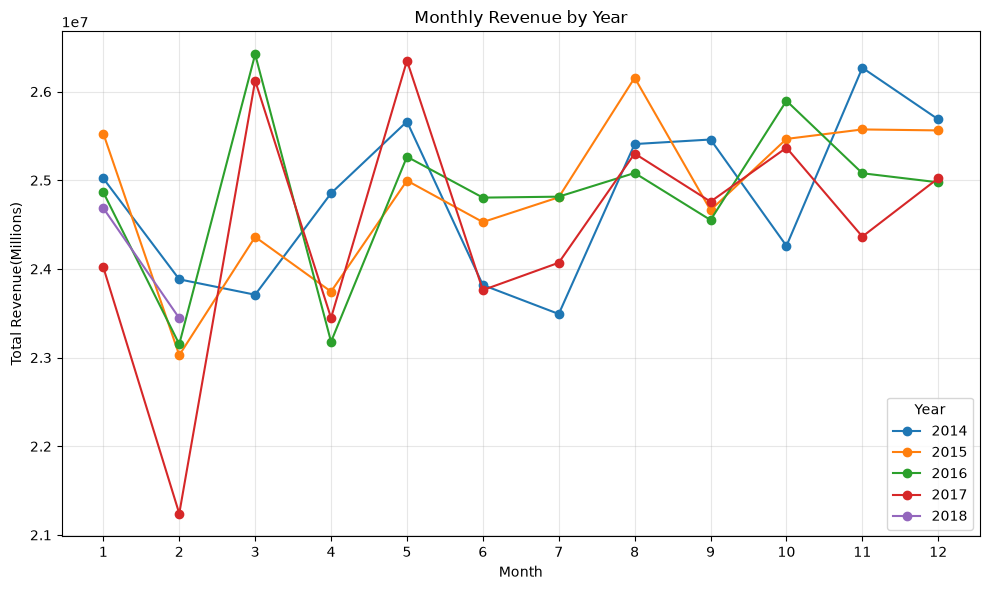

In [ ]:
## Plotting Monthly revenue for every year

df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

monthly_sales = df.groupby(['year', 'month'])['revenue'].sum().reset_index()
pivot_sales = monthly_sales.pivot(index='month', columns='year', values='revenue')

plt.figure(figsize=(10, 6))
for year in pivot_sales.columns:
    plt.plot(pivot_sales.index, pivot_sales[year], marker='o', label=str(year))

plt.xlabel('Month')
plt.ylabel('Total Revenue(Millions)')
plt.title('Monthly Revenue by Year')
plt.xticks(range(1, 13))
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Insights

1. Revenue exhibits clear seasonal fluctuations across multiple years.
2. Certain months consistently generate higher revenue, indicating recurring seasonal demand.
3. Revenue patterns differ across years, suggesting changing customer behavior or business growth.
4. Seasonal peaks may help optimize inventory planning and marketing campaigns.

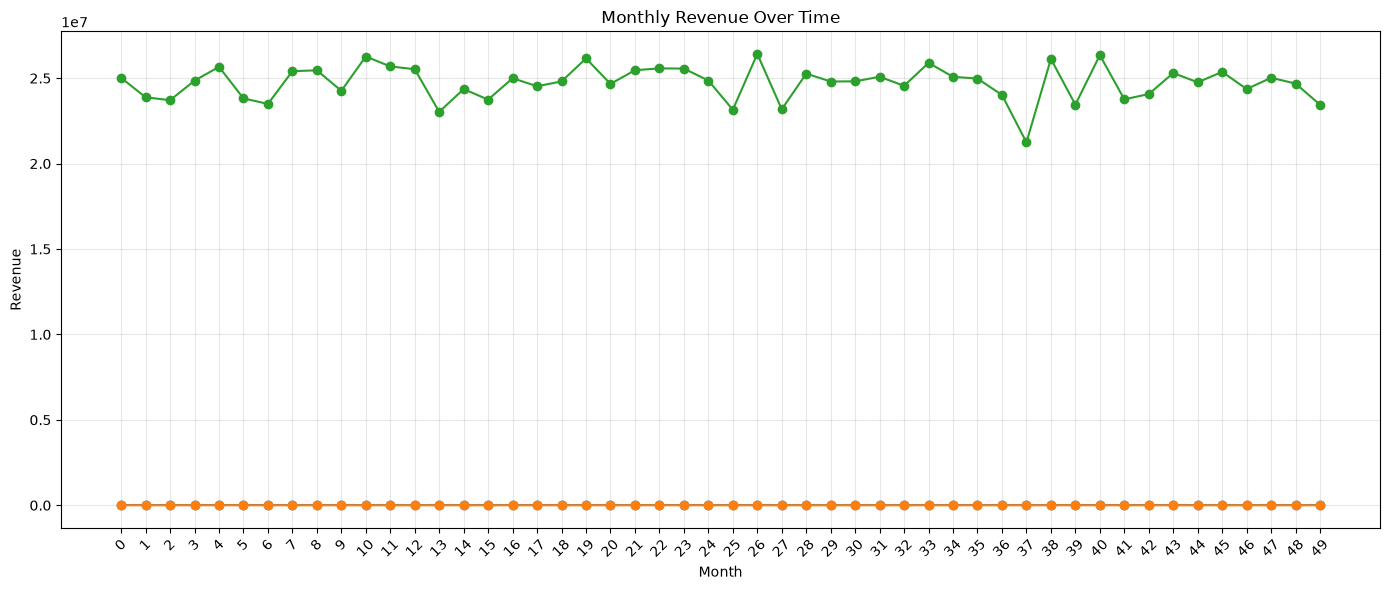

In [ ]:
## Ploting revenue acrosss the year in one continuous line graph 

x_labels = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 6))
plt.plot(x_labels, monthly_sales.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Insights

1. Temporary declines indicate seasonal slowdowns rather than long-term performance issues.
2. Overall business performance appears stable with recurring revenue cycles.

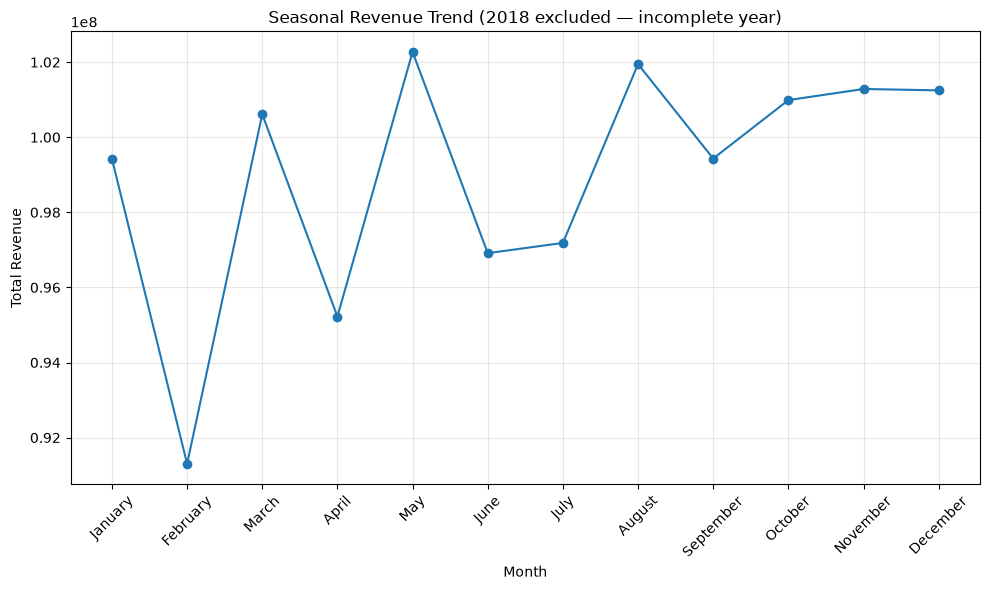

In [ ]:
## Ploting Aggregated revenue Of months over the year 

df['order_month_name'] = df['order_date'].dt.month_name()

df['order_month_num'] = df['order_date'].dt.month

monthly_sales = df.groupby(['order_month_num', 'order_month_name'])['revenue'].sum().sort_index()

import matplotlib.pyplot as plt

df_filtered = df[df['order_date'].dt.year != 2018]

monthly_sales = df_filtered.groupby(['order_month_num', 'order_month_name'])['revenue'].sum().sort_index()
monthly_sales_reset = monthly_sales.reset_index()

plt.figure(figsize=(10, 6))
plt.plot(monthly_sales_reset['order_month_name'], monthly_sales_reset['revenue'], marker='o')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Seasonal Revenue Trend (2018 excluded — incomplete year)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Insights

1. Some months consistently outperform others in revenue generation.
2. High-performing months may coincide with holidays, promotions, or festivals
3. Low-sales months represent opportunities for targeted marketing campaigns.

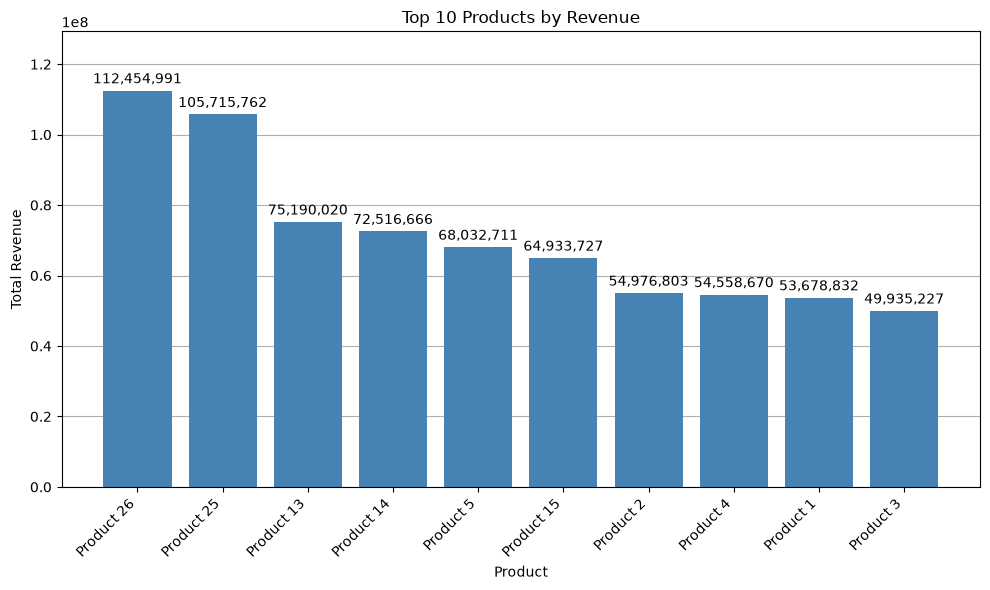

In [71]:
import matplotlib.pyplot as plt

top_products = df_filtered.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_products.index, top_products.values, color='steelblue')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=1)
plt.gca().set_axisbelow(True)
plt.ylim(0, top_products.values.max() * 1.15)
plt.bar_label(bars, labels=[f'{v:,.0f}' for v in top_products.values], padding=3)
plt.tight_layout()
plt.show()

#### Insights

1. A small number of products contribute a significant portion of total revenue.
2. These products should receive priority in inventory management and marketing.

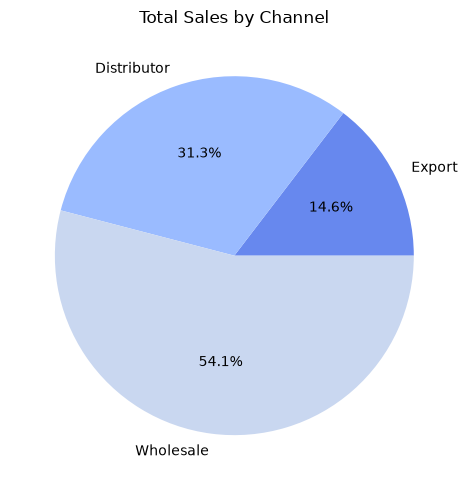

In [72]:
## Sales by Channel

chan_sale = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5,5))

plt.pie(
    chan_sale.values,
    labels=chan_sale.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by Channel')
plt.tight_layout()
plt.show()


#### Insights

1. Wholesale channel contributes the 54.1%(majority) of total revenue.
2. Lower-performing channels present opportunities for improvement.


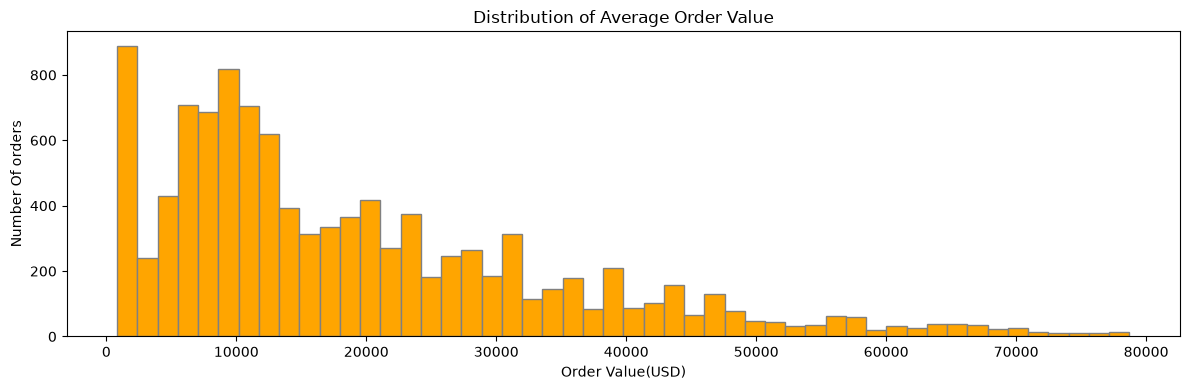

In [76]:
## Average Order value Distribution

AOV = df.groupby('order_number')['revenue'].mean()

plt.figure(figsize=(12,4))

plt.hist(
    AOV,
    bins=50,
    color='orange',
    edgecolor = 'grey'

)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value(USD)')
plt.ylabel('Number Of orders')

plt.tight_layout()
plt.show()

#### Insights

1. Most orders fall within a relatively narrow price range.
2. A few high-value orders create a long right tail.


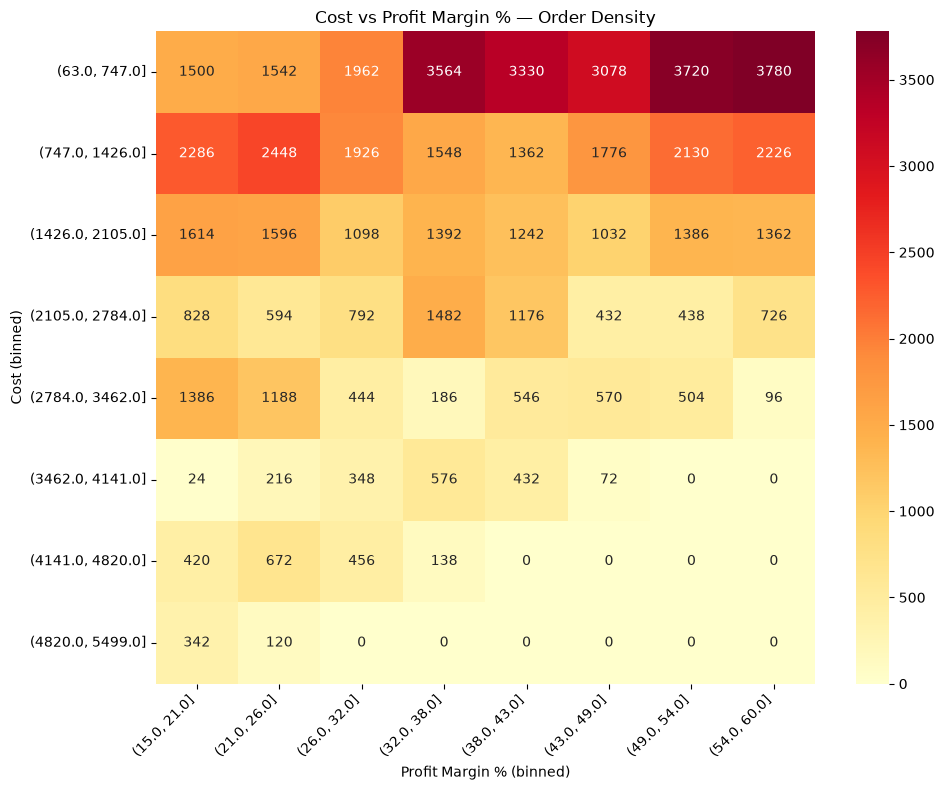

In [ ]:
## Cost vs Profit Margin heatmap 
cost_bins = pd.cut(df['cost'], bins=8, precision=0)
margin_bins = pd.cut(df['profit_margin_pct'], bins=8, precision=0)

heatmap_data = pd.crosstab(cost_bins, margin_bins)

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d')
plt.xlabel('Profit Margin % (binned)')
plt.ylabel('Cost (binned)')
plt.title('Cost vs Profit Margin % — Order Density')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Insights

1. Higher product cost does not necessarily translate into higher profit margins. As Products with higher cost generating lower profit margin percentage  
2. Most transactions are concentrated within moderate cost and moderate margin ranges.
3. Pricing strategy appears to influence profitability more than production cost alone.

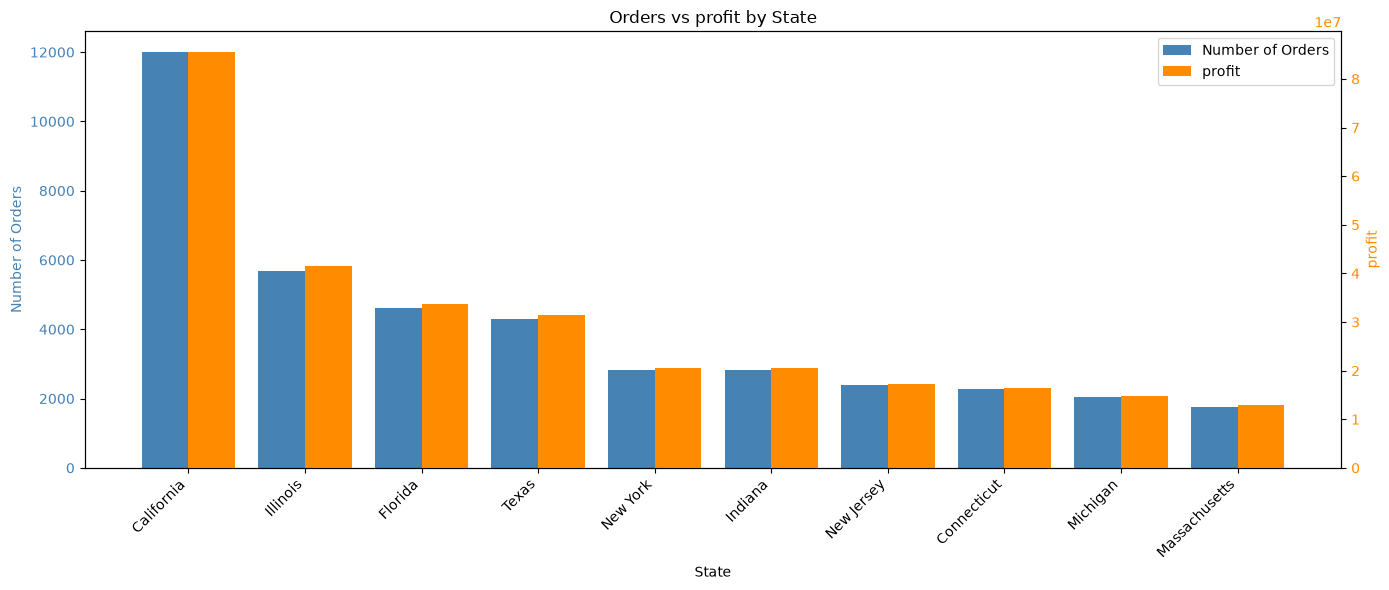

In [ ]:
## Number of orders and profit for different States
state_summary = df.groupby('state').agg(
    order_count=('order_number', 'count'),
    total_profit=('profit', 'sum')
).sort_values('total_profit', ascending=False).head(10)

x = np.arange(len(state_summary))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, state_summary['order_count'], width, color='steelblue', label='Number of Orders')
bars2 = ax2.bar(x + width/2, state_summary['total_profit'], width, color='darkorange', label='profit')

ax1.set_xlabel('State')
ax1.set_ylabel('Number of Orders', color='steelblue')
ax2.set_ylabel('profit', color='darkorange')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_xticks(x)
ax1.set_xticklabels(state_summary.index, rotation=45, ha='right')
ax1.set_title('Orders vs profit by State')
ax1.legend(handles=[bars1, bars2], loc='upper right')

plt.tight_layout()
plt.show()

#### Insights

1. Profitability depends on product mix and pricing rather than sales volume alone.


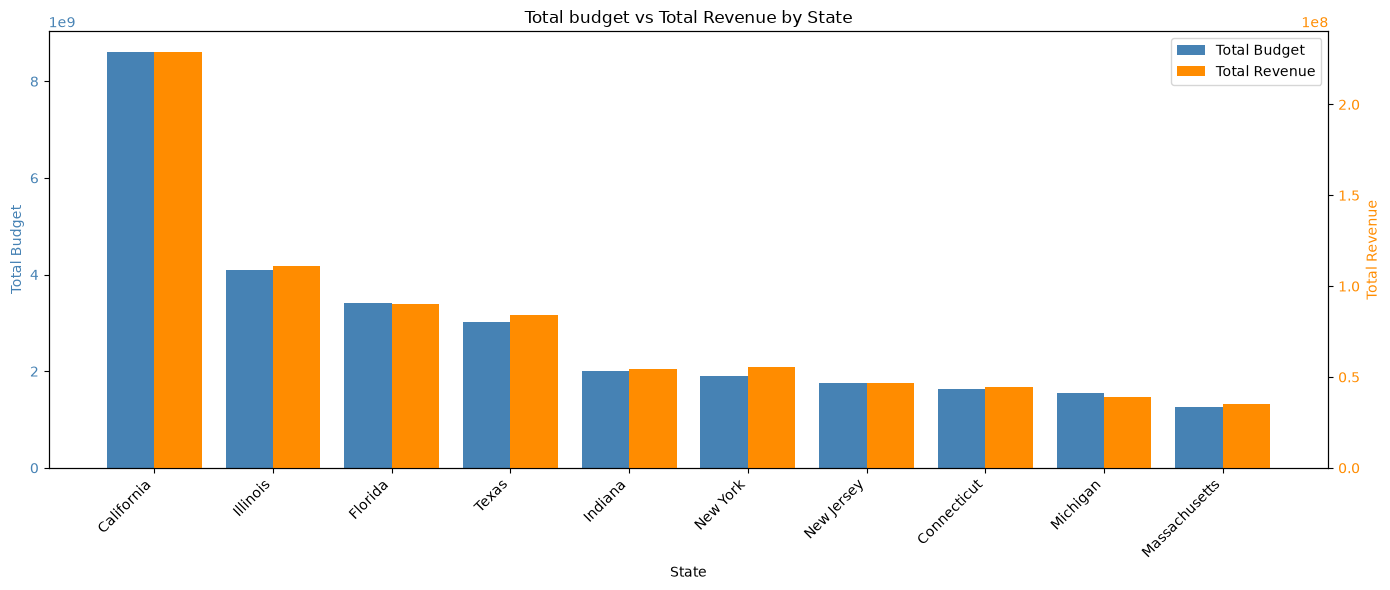

In [ ]:
## Total Budget with Total revenue for each States

state_summary = df.groupby('state').agg(
    total_revenue=('revenue', 'sum'),
    total_budget=('budget', 'sum')
).sort_values('total_budget', ascending=False).head(10)

x = np.arange(len(state_summary))
width = 0.4

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

bars1 = ax1.bar(x - width/2, state_summary['total_budget'], width, color='steelblue', label='Total Budget')
bars2 = ax2.bar(x + width/2, state_summary['total_revenue'], width, color='darkorange', label='Total Revenue')

ax1.set_xlabel('State')
ax1.set_ylabel('Total Budget', color='steelblue')
ax2.set_ylabel('Total Revenue', color='darkorange')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkorange')

ax1.set_xticks(x)
ax1.set_xticklabels(state_summary.index, rotation=45, ha='right')
ax1.set_title('Total budget vs Total Revenue by State')
ax1.legend(handles=[bars1, bars2], loc='upper right')

plt.tight_layout()
plt.show()

#### Insights

1. Higher budget allocation generally corresponds with higher revenue generation.
2. Some states outperform their allocated budget, indicating efficient resource utilization.
3. Other states may require budget optimization due to weaker returns.

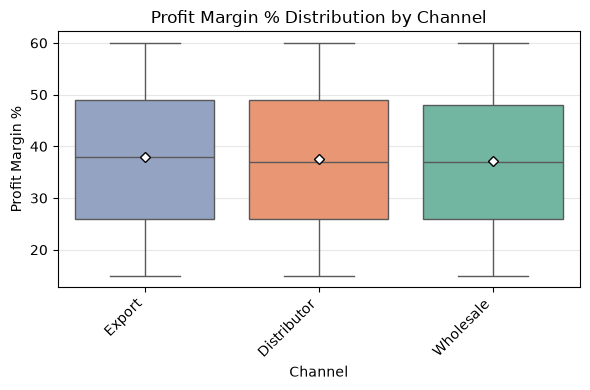

In [ ]:
### Profitable Margin Distribution For each Channel
channel_order = df.groupby('channel')['profit_margin_pct'].median().sort_values(ascending=False).index

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='channel', y='profit_margin_pct', order=channel_order,
            hue='channel', palette='Set2', legend=False,
            showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor': 'black', 'markersize': 5})
plt.xlabel('Channel')
plt.ylabel('Profit Margin %')
plt.title('Profit Margin % Distribution by Channel')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

#### Insights

1. Median profit margins differ noticeably across sales channels.
2. Channels with smaller variability provide more predictable business performance.
3. Channels with wide distributions indicate inconsistent profitability.

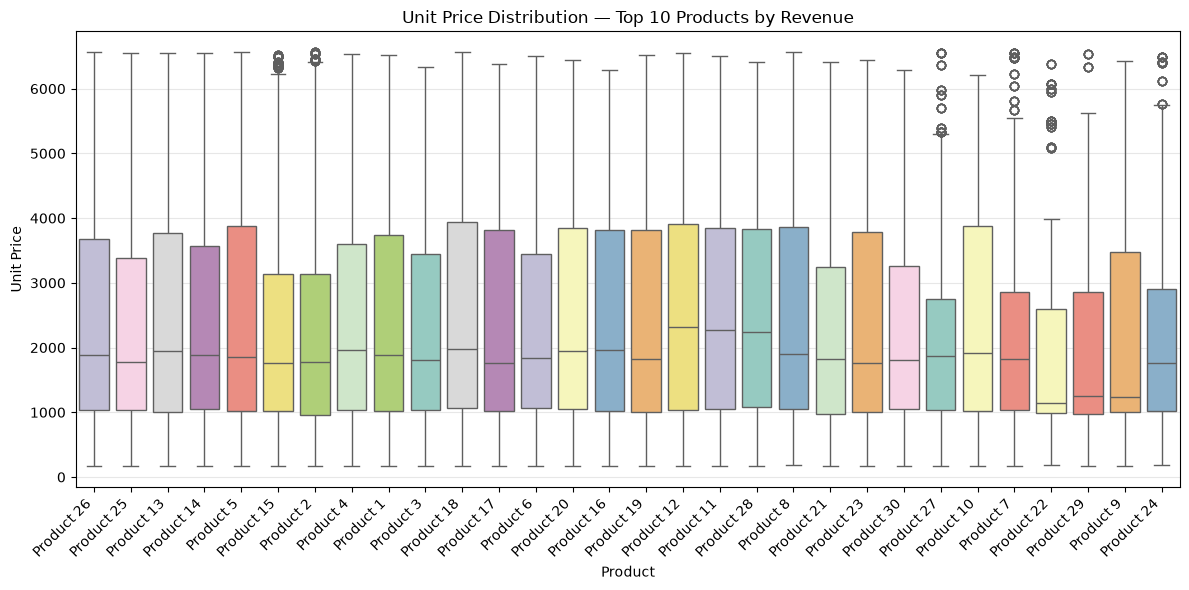

In [ ]:
## Unit Price Distribution by Products

top_products = df.groupby('product_name')['revenue'].sum().sort_values(ascending=False).index

df_top = df[df['product_name'].isin(top_products)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='product_name', y='unit_price', order=top_products,
            hue='product_name', palette='Set3', legend=False)
plt.xlabel('Product')
plt.ylabel('Unit Price')
plt.title('Unit Price Distribution — Top 10 Products by Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()

#### Insights

1. Certain products maintain relatively stable pricing.
2. Others show considerable price variation, possibly due to discounts or promotions.


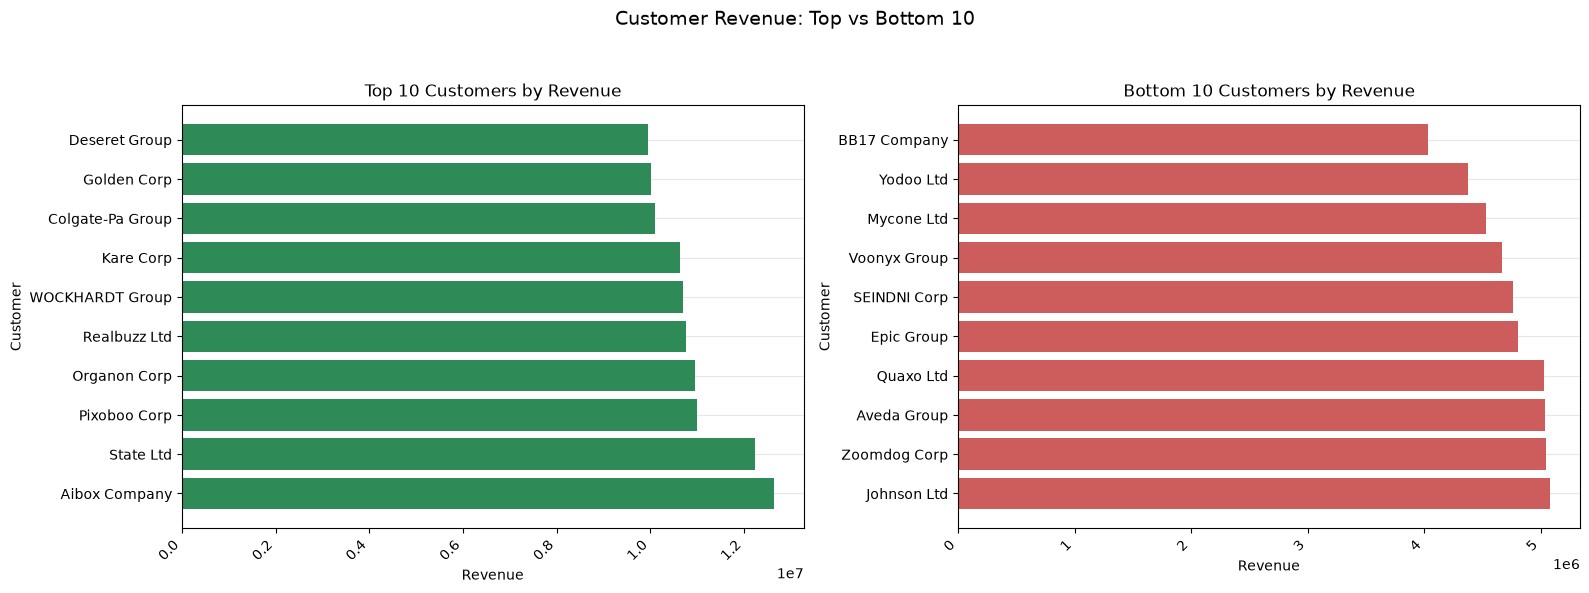

In [ ]:
## top 10 and Bottom 10 customers by Revenue

customer_revenue = df.groupby('custome_name')['revenue'].sum().sort_values(ascending=False)
top10 = customer_revenue.head(10)
bottom10 = customer_revenue.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10.index, top10.values, color='seagreen') 
axes[0].set_title('Top 10 Customers by Revenue')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Customer')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_axisbelow(True)

axes[1].barh(bottom10.index, bottom10.values, color='indianred')
axes[1].set_title('Bottom 10 Customers by Revenue')
axes[1].set_xlabel('Revenue')
axes[1].set_ylabel('Customer')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_axisbelow(True)

fig.suptitle('Customer Revenue: Top vs Bottom 10', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

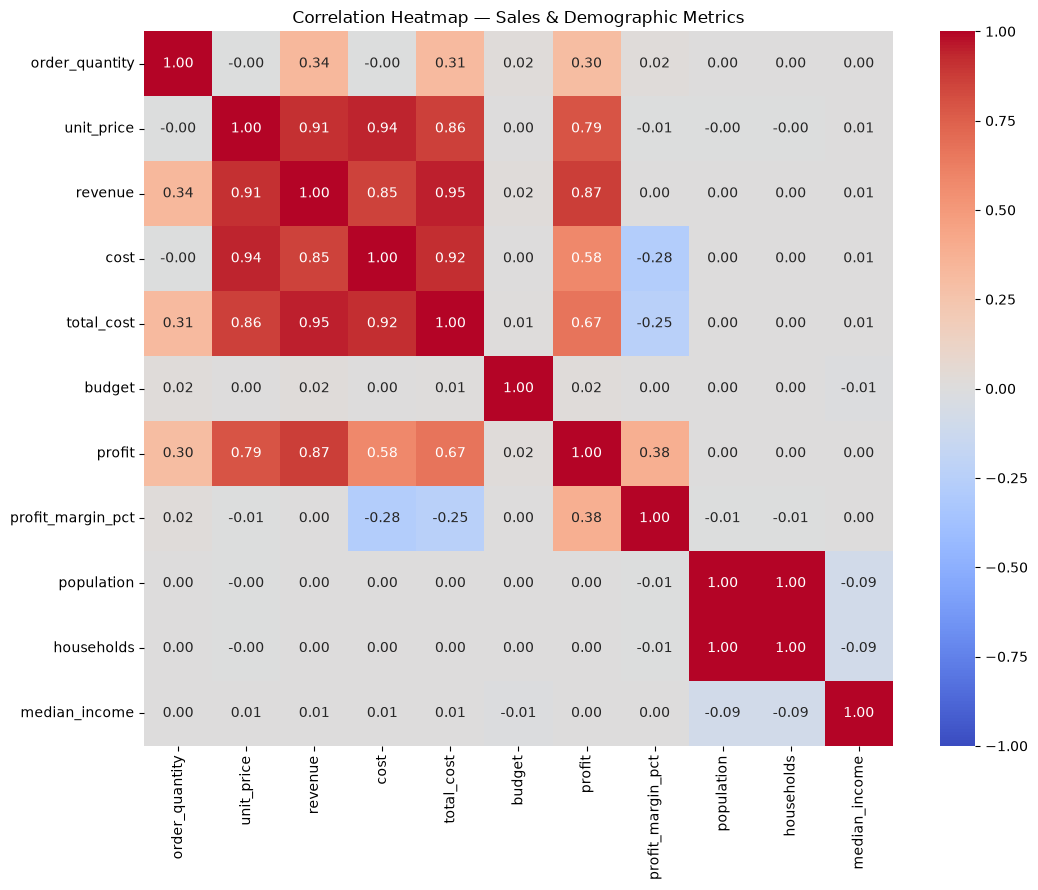

In [ ]:
## Correlation Heatmap

cols = ['order_quantity', 'unit_price', 'revenue', 'cost', 'total_cost',
        'budget', 'profit', 'profit_margin_pct', 'population', 'households', 'median_income']

corr_matrix = df[cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Sales & Demographic Metrics')
plt.tight_layout()
plt.show()

#### Insights

1. Revenue shows a strong positive correlation with Total Cost and Profit.
2. Profit Margin has weaker relationships with revenue, indicating pricing strategy also influences profitability.
3. Demographic variables exhibit relatively low correlations with financial metrics, suggesting limited direct impact on sales.

## Final Business Summary 

#### Key Business Findings

1. Sales exhibit noticeable seasonal patterns across the year.
2. A limited number of products generate the majority of total revenue, indicating a Pareto distribution.
3. Revenue is concentrated in a few high-performing customers and states.
4. Higher sales volume does not always translate into higher profitability.
5. Budget allocation generally aligns with revenue generation, although certain regions achieve better returns than others.
6. Profit margins vary considerably across sales channels, suggesting opportunities to optimize pricing and channel strategy.
7. Product pricing shows a mild inverse relationship with purchase quantity, indicating moderate customer price sensitivity.
8. Feature engineering enabled profitability analysis by introducing Total Cost, Profit, and Profit Margin metrics, providing deeper business insights beyond raw sales figures.

In [113]:
df.to_excel("C:/Users/Shivam Rajput/Desktop/Sales_Analysis(EDA).xlsx", index=False)